In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import PyGhostID package and 
import PyGhostID as gid

import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection
import pickle

# No warnings
import warnings
warnings.filterwarnings("ignore")

pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting

saveFigs = False

w:\GitHub\GhostID\paper\utils_paper.py


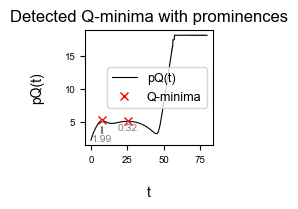

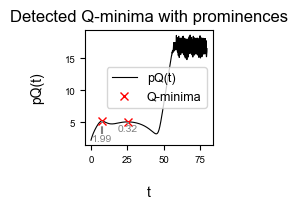

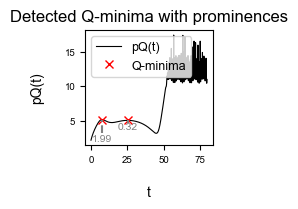

In [2]:

# set parameters
a = 2.0; y = 0.7; m = 0.15; g = 0.4; Nt = 0.53; N0 = 0.5; r = 1.8; c = 0.25
parameters_bieg =  [a,Nt,N0,g,y,r,c,m]

# simulate trajectory 
dt = 0.05
timesteps = np.linspace(0,80,int(80/dt))


for tol in [1e-9,1e-7,1e-5]:
    sol = solve_ivp(mod.bieg_etal, (0, 80), [0.05,0.8],
                        t_eval=timesteps, args=(parameters_bieg,),method='RK45',rtol=tol,atol=tol)

    # run ghostID
    Trj=sol.y.T
    ghostSeq, ctrlPlots = gid.ghostID(mod.bieg_etal,parameters_bieg,dt,Trj,peak_kwargs={"prominence":0.1,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

    # Plot control outputs from ghostID

    # pQ timeseries and Q-minima
    fig, ax = ctrlPlots[0]
    fig.set_size_inches(4.5*inCm,5.5*inCm)
    plt.figure(fig)
    if saveFigs: plt.savefig(f"SFig3_tol_{tol}.svg")
    plt.show()
